In [5]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [6]:
df_india=df.copy()
id(df_india)==id(df)

False

In [63]:
df_india= df_india[df_india['job_country']=='India']
df_india

df_india['job_posted_month'] = df_india['job_posted_date'].dt.strftime('%B')

df_india

df_india_pivot = df_india.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')


In [66]:
df_india_pivot = df_india_pivot.reset_index()
df_india_pivot['job_posted_month_no'] = pd.to_datetime(df_india_pivot['job_posted_month'], format='%B').dt.month
df_india_pivot = df_india_pivot.sort_values('job_posted_month_no')
df_india_pivot = df_india_pivot.set_index('job_posted_month')
df_india_pivot = df_india_pivot.drop(columns='job_posted_month_no')

df_india_pivot


job_title_short,index,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,,
January,4,175,31,628,2132,1444,70,127,448,269,192
February,3,143,35,433,1631,932,42,94,313,165,157
March,7,116,37,422,1591,1005,34,96,351,194,180
April,0,170,32,418,1566,946,54,86,375,194,169
May,8,103,14,278,1384,837,31,59,329,134,98
June,6,146,26,367,1632,1129,41,66,427,238,125
July,5,142,25,457,1528,1123,54,75,359,204,155
August,1,189,25,618,1407,1157,47,126,343,235,148
September,11,155,34,630,1508,984,67,85,324,195,132


job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_no
job_posted_month,,,,,,,,,,,
Jan,175,31,628,2132,1444,70,127,448,269,192,1
Feb,143,35,433,1631,932,42,94,313,165,157,2
Mar,116,37,422,1591,1005,34,96,351,194,180,3
Apr,170,32,418,1566,946,54,86,375,194,169,4
May,103,14,278,1384,837,31,59,329,134,98,5
Jun,146,26,367,1632,1129,41,66,427,238,125,6
Jul,142,25,457,1528,1123,54,75,359,204,155,7
Aug,189,25,618,1407,1157,47,126,343,235,148,8
Sep,155,34,630,1508,984,67,85,324,195,132,9


<Axes: xlabel='job_posted_month'>

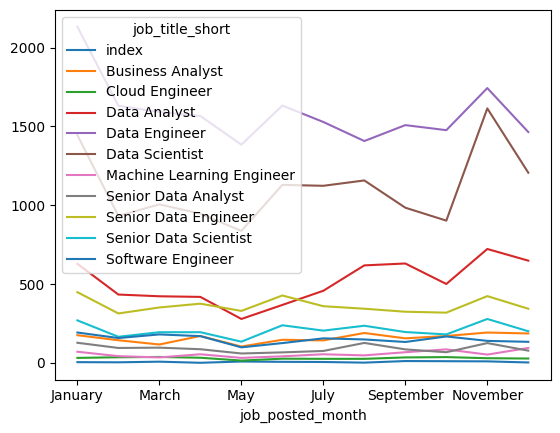

In [69]:
df_india_pivot.plot(kind='line')



In [71]:
top_3 = df_india['job_title_short'].value_counts().head(3)
top_3 = top_3.index.tolist()
top_3

['Data Engineer', 'Data Scientist', 'Data Analyst']

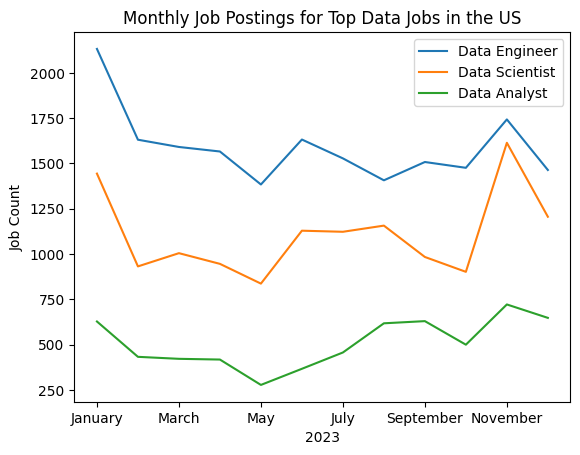

In [73]:
df_india_pivot[top_3].plot(kind='line')
plt.title('Monthly Job Postings for Top Data Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.legend()
plt.show()